In [42]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

### Engenharia de Features 

in_degree ==>	grau de entrada	N° de transações recebidas <br>
out_degree ==>	grau de saída	N° de transações realizadas<br>
pagerank ==>	pagerank	Influência na rede<br>
betweenness ==>	betweenness	Centralidade como ponte<br>
in_scc ==>	componente forte	1 se está num SCC com +1 conta<br>
scc_size ==>	componente forte	Tamanho do SCC da conta

In [101]:
import networkx as nx
import pandas as pd

# Carrega o dataset completo
df_transacoes = pd.read_csv(r"C:\Users\dpand\Documents\DSProjects2025\fraudeDetection_Grafos\base\transacoes_sinteticas_fraude_colusao.csv")

In [102]:
pd.set_option('display.max_columns', None)

### Construindo o G_full com todas as transações

In [103]:
# Cria grafo dirigido com todas as transações
G_full = nx.DiGraph()
for _, row in df_transacoes.iterrows():
    G_full.add_edge(row["id_origem"], row["id_destino"], valor=row["valor"])

### Cálculo de métricas de centralidade no grafo completo

In [104]:
# Importa o pacote necessário
import scipy  # necessário para o PageRank, verifique que está instalado

# Grau de entrada e saída
in_degrees = dict(G_full.in_degree())
out_degrees = dict(G_full.out_degree())

# PageRank
pagerank = nx.pagerank(G_full, alpha=0.85)

# Betweenness
betweenness = nx.betweenness_centrality(G_full)

# Cria DataFrame com métricas de centralidade
centralidade_df = pd.DataFrame({
    "id_conta": list(G_full.nodes),
    "in_degree": [in_degrees.get(n, 0) for n in G_full.nodes],
    "out_degree": [out_degrees.get(n, 0) for n in G_full.nodes],
    "pagerank": [pagerank.get(n, 0) for n in G_full.nodes],
    "betweenness": [betweenness.get(n, 0) for n in G_full.nodes]
})


### Análise dos SCCs no grafo completo

In [105]:
# Identifica todos os SCCs
sccs = list(nx.strongly_connected_components(G_full))

# Considera apenas os SCCs com tamanho >= 2 (para eliminar nós isolados)
sccs_maiores = [scc for scc in sccs if len(scc) > 1]

# Mapeia cada conta ao tamanho do SCC ao qual ela pertence
scc_tamanho_por_no = {}
for scc in sccs_maiores:
    for node in scc:
        scc_tamanho_por_no[node] = len(scc)

# Cria features no dataframe de centralidade
centralidade_df["in_scc"] = centralidade_df["id_conta"].apply(lambda x: 1 if x in scc_tamanho_por_no else 0)
centralidade_df["scc_size"] = centralidade_df["id_conta"].apply(lambda x: scc_tamanho_por_no.get(x, 0))


### Merge das features com o dataset de transações

In [106]:
# Merge por conta de origem
base_transacoes_com_features = df_transacoes.merge(
    centralidade_df.add_prefix("origem_"),
    left_on="id_origem",
    right_on="origem_id_conta",
    how="left"
)

# Merge por conta de destino
base_transacoes_com_features = base_transacoes_com_features.merge(
    centralidade_df.add_prefix("dest_"),
    left_on="id_destino",
    right_on="dest_id_conta",
    how="left"
)

# Remove colunas auxiliares de ID
base_transacoes_com_features.drop(columns=["origem_id_conta", "dest_id_conta"], inplace=True)


In [107]:
base_transacoes_com_features.head()

,id_transacao,id_origem,id_destino,valor,data_transacao,canal,tipo_conta_origem,tipo_conta_destino,instituicao_origem,instituicao_destino,localizacao_origem,localizacao_destino,dispositivo_origem,ip_origem,fingerprint,fraude,origem_in_degree,origem_out_degree,origem_pagerank,origem_betweenness,origem_in_scc,origem_scc_size,dest_in_degree,dest_out_degree,dest_pagerank,dest_betweenness,dest_in_scc,dest_scc_size
0,T000000,C00271,C01093,118.90,2025-02-11 19:31:00,DOC,Pessoa Jurídica,Pessoa Física,Banco Digital X,Banco A,Gonçalves,Cardoso,caixa_eletronico,64.223.243.188,436c8b2b8cf5,0,8,9,0.000983,0.003354,1,1494,4,5,0.000302,7.896563e-04,1,1494
1,T000001,C00349,C00338,68.99,2025-01-27 11:50:00,PIX,Pessoa Jurídica,Pessoa Jurídica,Banco Digital X,Banco A,Lopes,Cardoso,web,141.21.172.223,f5dae2e0e1e1,0,4,8,0.000281,0.001230,1,1494,8,7,0.000748,2.124252e-03,1,1494
2,T000002,C00309,C00289,253.83,2025-01-12 14:32:00,DOC,Pessoa Jurídica,Pessoa Física,Wallet Y,Banco A,Cunha,Monteiro Verde,mobile,37.138.55.85,0eebc817d919,0,6,6,0.000579,0.001260,1,1494,12,9,0.001235,5.258348e-03,1,1494
3,T000003,FRAUD130,FRAUD131,768.89,2025-03-10 17:30:00,TRANSFERÊNCIA INTERNA,Pessoa Física,Pessoa Física,Banco Digital X,Banco Digital X,Carvalho da Praia,Carvalho da Praia,web,192.168.1.27,99b9084ee732,1,0,2,0.000092,0.000000,0,0,2,2,0.000367,1.806860e-07,1,4
4,T000004,C00965,C00632,24.42,2025-03-13 02:40:00,BOLETO,Pessoa Física,Pessoa Física,Banco Digital X,Banco Digital X,Dias do Campo,Almeida de da Conceição,web,49.250.115.168,febda6c02676,0,3,8,0.000248,0.000989,1,1494,9,8,0.000733,3.121229e-03,1,1494


In [108]:
base_transacoes_com_features.shape

(9995, 28)

In [109]:
base_transacoes_com_features.columns

Index(['id_transacao', 'id_origem', 'id_destino', 'valor', 'data_transacao',
       'canal', 'tipo_conta_origem', 'tipo_conta_destino',
       'instituicao_origem', 'instituicao_destino', 'localizacao_origem',
       'localizacao_destino', 'dispositivo_origem', 'ip_origem', 'fingerprint',
       'fraude', 'origem_in_degree', 'origem_out_degree', 'origem_pagerank',
       'origem_betweenness', 'origem_in_scc', 'origem_scc_size',
       'dest_in_degree', 'dest_out_degree', 'dest_pagerank',
       'dest_betweenness', 'dest_in_scc', 'dest_scc_size'],
      dtype='object')

### Seleção das colunas a normalizar

In [110]:
from sklearn.preprocessing import MinMaxScaler

# Lista de colunas numéricas derivadas de grafos
colunas_grafo_numericas = [
    'origem_in_degree', 'origem_out_degree', 'origem_pagerank', 'origem_betweenness',
    'origem_scc_size', 'dest_in_degree', 'dest_out_degree', 'dest_pagerank',
    'dest_betweenness', 'dest_scc_size'
]

# Verifica se existem colunas ausentes (por precaução)
colunas_existentes = [col for col in colunas_grafo_numericas if col in base_transacoes_com_features.columns]

# Cria uma cópia segura do DataFrame
df_modelo = base_transacoes_com_features.copy()

In [111]:
scaler = MinMaxScaler()

# Aplica o MinMaxScaler nas colunas de grafos
df_modelo[colunas_existentes] = scaler.fit_transform(df_modelo[colunas_existentes])

In [112]:
print(df_modelo[colunas_existentes].describe())


       origem_in_degree  origem_out_degree  origem_pagerank  \
count       9995.000000        9995.000000      9995.000000   
mean           0.405589           0.404802         0.319156   
std            0.172552           0.176985         0.152290   
min            0.000000           0.000000         0.000000   
25%            0.266667           0.266667         0.205697   
50%            0.400000           0.400000         0.299788   
75%            0.533333           0.533333         0.413875   
max            1.000000           1.000000         1.000000   

       origem_betweenness  origem_scc_size  dest_in_degree  dest_out_degree  \
count         9995.000000      9995.000000     9995.000000      9995.000000   
mean             0.260206         0.948509        0.430615         0.380359   
std              0.155289         0.220704        0.185043         0.163481   
min              0.000000         0.000000        0.000000         0.000000   
25%              0.155697         1.0

In [122]:
from sklearn.preprocessing import LabelEncoder

# Copia o DataFrame original
df_encoded = df_modelo.copy()

# Lista de colunas que serão removidas (IDs)
drop_cols = ['id_origem', 'id_destino']

# Remove colunas que não devem ser usadas
df_encoded.drop(columns=drop_cols, inplace=True)

# Transforma 'data_transacao' em variáveis temporais (hora, dia da semana etc.)
df_encoded['data_transacao'] = pd.to_datetime(df_encoded['data_transacao'])
df_encoded['hora'] = df_encoded['data_transacao'].dt.hour
df_encoded['dia_semana'] = df_encoded['data_transacao'].dt.dayofweek
df_encoded.drop(columns=['data_transacao'], inplace=True)

# Colunas que precisam de Label Encoding
colunas_label = [
    'canal', 'tipo_conta_origem', 'tipo_conta_destino', 
    'instituicao_origem', 'instituicao_destino', 
    'localizacao_origem', 'localizacao_destino', 
    'dispositivo_origem', 'ip_origem', 'fingerprint'
]

# Aplicando Label Encoding
label_encoders = {}
for col in colunas_label:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le  # Guarda o encoder caso queira reverter depois


### Preparando os dados para Feature Selection

In [123]:
df_encoded1 = df_encoded.copy()

In [124]:
# Remove a coluna id_transacao se ela estiver presente
if 'id_transacao' in df_encoded1.columns:
    df_encoded1.drop(columns=['id_transacao'], inplace=True)

In [125]:
from sklearn.model_selection import train_test_split

# Define X e y
X = df_encoded1.drop(columns=['fraude'])  # Todas as colunas exceto a target
y = df_encoded1['fraude']

# Divide treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### Univariate Selection – SelectKBest

In [73]:
from sklearn.feature_selection import SelectKBest, chi2

# Aplica o teste
selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_train.fillna(0), y_train)

# Resultados em DataFrame
kbest_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print(kbest_scores)


                Feature          Score
0                 valor  429158.646383
9             ip_origem   37924.459481
6    localizacao_origem     747.967002
7   localizacao_destino     396.189372
16      origem_scc_size     324.537037
22        dest_scc_size     324.344623
10          fingerprint     195.415514
3    tipo_conta_destino     164.063878
2     tipo_conta_origem     162.494827
5   instituicao_destino     157.830288
4    instituicao_origem     154.448974
14   origem_betweenness      89.889269
20     dest_betweenness      89.476038
12    origem_out_degree      81.337340
17       dest_in_degree      79.858401
8    dispositivo_origem      72.928058
11     origem_in_degree      62.338582
18      dest_out_degree      58.185127
15        origem_in_scc       3.465968
23                 hora       0.725512
13      origem_pagerank       0.432316
24           dia_semana       0.402123
21          dest_in_scc       0.371336
19        dest_pagerank       0.035156
1                 canal  

### Feature Importance com Random Forest

In [74]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train.fillna(0), y_train)

importancias_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importancias_rf)


                Feature  Importance
16      origem_scc_size    0.244224
14   origem_betweenness    0.207550
20     dest_betweenness    0.177054
22        dest_scc_size    0.169058
12    origem_out_degree    0.057485
17       dest_in_degree    0.044988
18      dest_out_degree    0.036106
9             ip_origem    0.022396
0                 valor    0.015976
11     origem_in_degree    0.010784
4    instituicao_origem    0.002767
5   instituicao_destino    0.002720
2     tipo_conta_origem    0.002608
3    tipo_conta_destino    0.002414
15        origem_in_scc    0.001026
13      origem_pagerank    0.000805
21          dest_in_scc    0.000708
19        dest_pagerank    0.000706
8    dispositivo_origem    0.000310
7   localizacao_destino    0.000097
6    localizacao_origem    0.000063
10          fingerprint    0.000061
1                 canal    0.000043
23                 hora    0.000030
24           dia_semana    0.000022


### L1 Regularization (Lasso com LogisticRegression)

In [117]:
X_train

,id_transacao,id_origem,id_destino,valor,canal,tipo_conta_origem,tipo_conta_destino,instituicao_origem,instituicao_destino,localizacao_origem,localizacao_destino,dispositivo_origem,ip_origem,fingerprint,origem_in_degree,origem_out_degree,origem_pagerank,origem_betweenness,origem_in_scc,origem_scc_size,dest_in_degree,dest_out_degree,dest_pagerank,dest_betweenness,dest_in_scc,dest_scc_size
3428,T003428,C00714,C01191,6.13,TRANSFERÊNCIA INTERNA,Pessoa Física,Pessoa Jurídica,Banco A,Banco Digital X,Sales de Barros,Ribeiro de Jesus,web,232.97.116.243,4fe5d9556be8,0.733333,0.466667,0.379298,0.465914,1,1.0,0.500000,0.5625,0.260052,0.401881,1,1.0
3538,T003538,C00934,C00039,225.47,TED,Pessoa Jurídica,Pessoa Física,Banco A,Banco B,Peixoto Paulista,Gomes,web,213.116.144.193,12fc83be0c15,0.600000,0.600000,0.480115,0.551686,1,1.0,0.357143,0.5625,0.367947,0.398514,1,1.0
409,T000409,C00634,C00161,388.19,TED,Pessoa Física,Pessoa Jurídica,Banco Digital X,Wallet Y,Aragão,Correia,caixa_eletronico,205.33.158.223,68a27bbf7919,0.333333,0.466667,0.272281,0.271759,1,1.0,0.428571,0.6250,0.330071,0.415877,1,1.0
4883,T004883,C01417,C00745,969.87,TED,Pessoa Física,Pessoa Jurídica,Banco B,Wallet Y,Cardoso de da Luz,Santos,mobile,36.252.11.173,c0d47567b950,0.266667,0.400000,0.385681,0.242450,1,1.0,0.142857,0.7500,0.199764,0.245568,1,1.0
3846,T003846,C00257,C01177,136.18,BOLETO,Pessoa Física,Pessoa Física,Banco B,Banco A,Alves do Campo,Cavalcanti das Flores,caixa_eletronico,76.224.64.123,ae36885974fd,0.533333,0.333333,0.293007,0.228688,1,1.0,0.500000,0.4375,0.321343,0.283457,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,T005734,C01455,C00827,514.79,DOC,Pessoa Física,Pessoa Física,Wallet Y,Banco Digital X,Souza,Lopes de Fogaça,web,27.188.86.97,c2c7ddc5f6d5,0.400000,0.333333,0.316030,0.241307,1,1.0,0.785714,0.5625,0.666346,0.563899,1,1.0
5191,T005191,C00581,C01056,470.53,TRANSFERÊNCIA INTERNA,Pessoa Jurídica,Pessoa Física,Banco B,Banco C,Ribeiro de Cavalcanti,Teixeira,mobile,216.101.75.12,52781f1f8c5a,0.266667,0.466667,0.129640,0.157666,1,1.0,0.571429,0.1250,0.411034,0.081704,1,1.0
5390,T005390,C01250,C00852,321.87,PIX,Pessoa Física,Pessoa Jurídica,Banco Digital X,Banco C,Caldeira das Flores,da Luz,web,67.149.16.122,743035f184d9,0.333333,0.400000,0.348364,0.212351,1,1.0,0.285714,0.5000,0.251647,0.230521,1,1.0
860,T000860,C00480,C00947,156.52,DOC,Pessoa Jurídica,Pessoa Física,Banco B,Banco A,Barros da Praia,Rezende dos Dourados,mobile,243.16.78.194,556f82488e22,0.400000,0.333333,0.371051,0.271694,1,1.0,0.285714,0.3750,0.313290,0.219969,1,1.0


In [126]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Prever
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]


AUC: 1.0

Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2831
           1       1.00      1.00      1.00       168

    accuracy                           1.00      2999
   macro avg       1.00      1.00      1.00      2999
weighted avg       1.00      1.00      1.00      2999



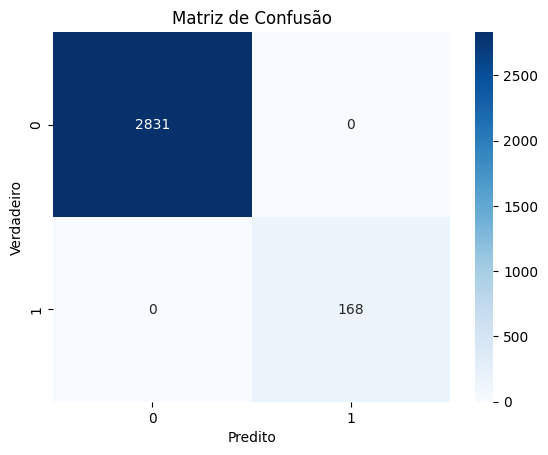

In [127]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

print("AUC:", roc_auc_score(y_test, y_proba))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

# Matriz de Confusão
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.title("Matriz de Confusão")
plt.show()


In [90]:
X_test.columns

Index(['valor', 'canal', 'tipo_conta_origem', 'tipo_conta_destino',
       'instituicao_origem', 'instituicao_destino', 'localizacao_origem',
       'localizacao_destino', 'dispositivo_origem', 'ip_origem', 'fingerprint',
       'origem_in_degree', 'origem_out_degree', 'origem_pagerank',
       'origem_betweenness', 'origem_in_scc', 'origem_scc_size',
       'dest_in_degree', 'dest_out_degree', 'dest_pagerank',
       'dest_betweenness', 'dest_in_scc', 'dest_scc_size', 'hora',
       'dia_semana'],
      dtype='object')

In [ ]:
features = ['valor', 'canal', 'tipo_conta_origem', 'tipo_conta_destino',
       'instituicao_origem', 'instituicao_destino', 'localizacao_origem',
       'localizacao_destino', 'dispositivo_origem', 'ip_origem', 'fingerprint',
       'origem_in_degree', 'origem_out_degree', 'origem_pagerank',
       'origem_betweenness', 'origem_in_scc', 'origem_scc_size',
       'dest_in_degree', 'dest_out_degree', 'dest_pagerank',
       'dest_betweenness', 'dest_in_scc', 'dest_scc_size', 'hora',
       'dia_semana']

In [86]:
X_test.shape

(2999, 25)

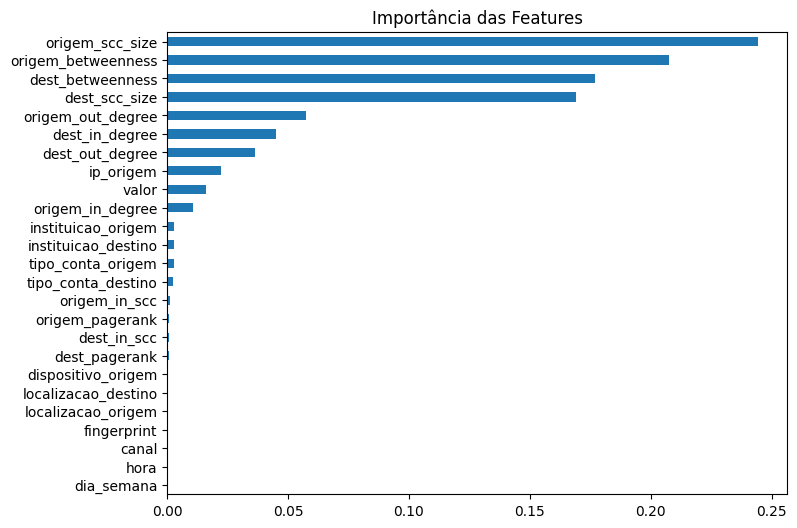

In [ ]:
importances = pd.Series(clf.feature_importances_, index=features)
importances.sort_values(ascending=True).plot(kind="barh", figsize=(8, 6))
plt.title("Importância das Features")
plt.show()

Nota: O modelo está claramente sofrendo com overfitting. Veremos possíveis soluções!